#Trabalho prático # 1
##Modelagem matemática e Computacional

###Tópico: Força e movimento

---

Nome: Maria Luiza Pinheiro Ferreira

DRE: 124167281


---

**Instruções:**

**Faça uma cópia deste notebook no seu drive, preencha-lo com seus dados, escreva e execute seus códigos antes de entregar o trabalho.**

**Inclua  um relatório, na parte final do notebook,** com suas conclusões, respostas, observações e comentários relacionados às questões abordadas nas tarefas.  

**A elaboração dos códigos pode ser realizada em duplas, mas o resto do trabalho é individual.**

**Não é permitido o uso de IA no desenvolvimento do trabalho.**

*Se você fez o seu trabalho em dupla inclua essa informação no relatório. Além disso, se você  também recebeu ajuda de um(a) colega/amigo(a) ou consultou/usou informações da internet ou outras fontes, coloque referências à elas no seu relatório.*


**Entrega do trabalho:**

*Na entrega do seu trabalho, inclua  o arquivo do seu notebook (.ipynb) diretamente do seu google drive. **Não serão aceitos links para o arquivo**.*

*Data de entrega: 12/junho/2026*

---


A força de atração gravitacional que um corpo de massa $m_1$ exerce no corpo de massa $m_2$ é modelada segundo a lei de gravitação universal de Newton, dada pela equação $$\vec{F}_{12} =  -\frac{Gm_1m_2}{{r}^2}\vec{e}_{12}$$
em que $G$ é a constante de gravitação universal, $r$ a distância entre os corpo e $\vec{e}_{12}$ o vetor unitário direcionado do primeiro para o segundo corpo.

Na modelagem do movimento de corpos celestes no sistema solar é usado o seguinte sistema de unidades fundamentais:

* Comprimento: $1 \,{AU}$ (Unidade Astronômica $\approx$ Distância média Terra-Sol);
* Massa: $1 \,{M}_{\odot}$ (Massa do Sol $\approx 1.98\times 10^{30}\,kg$);
* Tempo: $1\,ano$.

Para a constante de gravitação universal temos que
$$ G = 4\pi^2\;\frac{AU^3}{{M}_{\odot}\times ano^2}.$$


##Tarefa #1:

Implemente um código em Python para simular o movimento do sistema Sol-Terra.

a)  Calcule a evolução do sistema para um período de $2\,\text{anos}$, usando os seguintes dados:


*   Terra:
    1.   Posição inicial: $x_0 = 0.9832\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.0\,AU/ano$, $\quad v_{0y} = 6.2835\,AU/ano$,
    3.   Massa: $m_1 = 3.003\times 10^{-6}\,{M}_{\odot}$
*   Sol:
    1.   Posição inicial: $x_0 = -2.95\times 10^{-6}\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.0\,AU/ano$, $\quad v_{0y} = -1.887\times 10^{-5}\,AU/ano$,
    3.   Massa: $m_2 = 1\,{M}_{\odot}$


b) Mostre os gráficos das trajetórias de cada corpo no plano $XY$, da evolução das coordenadas de cada corpo e da distância entre os dois corpos ao longo do tempo.


---


**Observação**: Use as funcionalidades do [NumPy](https://numpy.org)  para trabalhar com  vetores (*arrays* de dados), do [SciPy](https://scipy.org/) para a resolução de problemas para EDOs (função [solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html#scipy.integrate.solve_ivp)) e do [MatPlotLib](https://matplotlib.org/) para a visualização dos resultados.

In [22]:
#Tarefa 1- letra a)

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

"""
a) Calcule a evolução do sistema para um período de  2anos , usando os seguintes dados:
  Terra:
  x0 = 0.9832
  y0 = 0.0
  v0x = 0.0
  v0y = 6.2835
  m1 = 3.003*pow(10,-6) => 3.003e-06

  Sol:
  x0 = -(2.95*pow(10,-6)) =>  -2.95e-06
  y0 = 0.0
  v0x = 0.0
  v0y = -(1.887*pow(10,-5)) => -1.887e-05
  m2 = 1.0
"""
G = 4 * np.pi**2
tf = 2.0

#Condições iniciais Terra
rT0 = np.array([0.9832,0])
vT0 = np.array([0,6.2835])
mT = 3.003e-06

#Condições iniciais Sol
rS0 = np.array([-2.95e-06,0])
vS0 = np.array([0,-1.887e-05])
mS = 1.0

# Estado inicial
Y0 = np.concatenate((rT0, vT0, rS0, vS0))

def sistema(t,Y):
  rT = Y[0:2]
  vT = Y[2:4]

  rS = Y[4:6]
  vS = Y[6:8]

  r = rT - rS
  r_mod = np.linalg.norm(r)
  e = r / r_mod

  # F = ma, então a aceleração será:
  aT = - (G * mS / r_mod**2) * e
  aS =  (G * mT / r_mod**2) * e

  return np.concatenate([vT, aT, vS, aS])

# Pontos de tempo
t = np.linspace(0, tf, num=1000)

# Resolução numérica com solve_ivp
sol = solve_ivp(sistema, (0, tf), Y0, t_eval=t)

print(sol.success)
t = sol.t
xT = sol.y[0]
yT = sol.y[1]
vxT = sol.y[2]
vyT = sol.y[3]

xS = sol.y[4]
yS = sol.y[5]
vxS = sol.y[6]
vyS = sol.y[7]

print("Posição final da Terra:" , xT[-1], yT[-1])
print("Velocidade final da Terra:" , vxT[-1], vyT[-1])
print("Posição final do Sol:" , xS[-1], yS[-1])
print("Velocidade final do Sol:" , vxS[-1], vyS[-1])

True
Posição final da Terra: -0.6610163671842793 0.4537969682022426
Velocidade final da Terra: -3.9166321525278236 -5.8674670950851615
Posição final do Sol: 1.9875817506543816e-06 -1.364051295511326e-06
Velocidade final do Sol: 1.1761646354041036e-05 1.7619354186540718e-05


In [1]:
#Tarefa 1- letra b)

"""
Mostre os gráficos das trajetórias de cada corpo no plano  XY,
da evolução das coordenadas de cada corpo e da distância entre os dois corpos ao longo do tempo

"""

# Gráfico de trajetória da Terra e do Sol separados
plt.plot(xT,yT)
plt.scatter(xT[0],yT[0], marker="o")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Trajetória da Terra")
plt.grid(True)
plt.axis("equal")
plt.show()


plt.plot(xS,yS, color ="red")
plt.scatter(xS[0],yS[0], marker="o", color="red")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Trajetória do Sol")
plt.grid(True)
plt.axis("equal")
plt.show()

# Grafico da evolução das coordenadas de cada corpo ao longo do tempo
plt.plot(t,xT)
plt.plot(t,yT)
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Evolução das coordenadas da Terra")
plt.grid(True)
plt.show()

plt.plot(t,xS, color ="green")
plt.plot(t,yS, color ="red")
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Evolução das cordenadas do Sol")
plt.grid(True)
plt.show()

# Grafico da distância entre os dois corpos ao longo do tempo
dist = np.sqrt((xT - xS)**2 + (yT - yS)**2)

plt.plot(t, dist)
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Distância entre o Sol e Terra ao do tempo")
plt.grid(True)
plt.show()


NameError: name 'plt' is not defined

##Tarefa #2:

Implemente um código em Python para simular a evolução de um sistema de três estrelas.

a)  Calcule a evolução do sistema para um período de $10.5\,anos$. Use os seguintes dados:

*   Estrela 1:
    1.   Posição inicial: $x_0 = 0.970043\,AU$, $\quad y_0 = -0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.466203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_1 = 0.02533\,{M}_{\odot}$
*   Estrela 2:
    1.   Posição inicial: $x_0 = -0.970043\,AU$, $\quad y_0 = 0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.466203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_2 = 0.02533\,{M}_{\odot}$
*   Estrela 3:
    1.   Posição inicial: $x_0 = 0.0\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = -0.932406\,AU/ano$, $\quad v_{0y} = -0.864730\,AU/ano$,
    3.   Massa: $m_3 = 0.02533\,{M}_{\odot}$


b) Mostre os gráficos das trajetórias de cada estrela no plano $XY$, da evolução das coordenadas de cada estrela e das distâncias mutuas entre as estrelas ao longo do tempo.

c) Calcule a evolução do sistema para um período de $10.5\,anos$. Use os seguintes dados:

*   Estrela 1:
    1.   Posição inicial: $x_0 = 0.970043\,AU$, $\quad y_0 = -0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.166203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_1 = 0.02533\,{M}_{\odot}$
*   Estrela 2:
    1.   Posição inicial: $x_0 = -0.970043\,AU$, $\quad y_0 = 0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.766203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_2 = 0.02533\,{M}_{\odot}$
*   Estrela 3:
    1.   Posição inicial: $x_0 = 0.0\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = -0.932406\,AU/ano$, $\quad v_{0y} = -0.864730\,AU/ano$,
    3.   Massa: $m_3 = 0.02533\,{M}_{\odot}$

d) Mostre os gráficos das trajetórias de cada estrela no plano $XY$, da evolução das coordenadas de cada estrela e das distâncias mutuas entre as estrelas ao longo do tempo.

e) Descreva qualitativamente os movimentos do sistema calculados nos itens a) e c). Indique semelhanças e diferenças entre esses dois cenários.

In [24]:
#Tarefa 2- letra a)

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

"""
Calcule a evolução do sistema para um período de  10.5anos . Use os seguintes dados:

Estrela 1:
x0 = 0.970043 ,  y0 = −0.243087 ,
v0x = 0.466203 ,  v0y = 0.432365 ,
m1 = 0.02533

Estrela 2:
x0 = −0.970043 ,  y0 = 0.243087 ,
v0x = 0.466203 ,  v0y = 0.432365 ,
m2 = 0.02533

Estrela 3:
x0 = 0.0 ,  y0 = 0.0 ,
v0x = −0.932406,  v0y = −0.864730 ,
m3 = 0.02533
"""
G = 4 * np.pi**2
tf = 10.5

#Condições iniciais Estrela 1
r1 = np.array([0.970043 , -0.243087 ])
v1 = np.array([0.466203 , 0.432365 ])
m1 = 0.02533

#Condições iniciais Estrela 2
r2 = np.array([ -0.970043 , 0.243087 ])
v2 = np.array([ 0.466203 , 0.432365])
m2 = 0.02533

#Condições iniciais Estrela 3
r3 = np.array([ 0.0 , 0.0 ])
v3 = np.array([ -0.932406 , -0.864730])
m3 = 0.02533


# Estado inicial
m = np.array([m1, m2, m3])
Y0 = np.concatenate((r1, v1, r2, v2, r3, v3))

def sistema_3_estrela(t,Y):
  r1 = Y[0:2]
  v1 = Y[2:4]

  r2 = Y[4:6]
  v2 = Y[6:8]

  r3 = Y[8:10]
  v3 = Y[10:12]

  # Criando novos vetores
  pos = [r1,r2,r3]
  acel = np.zeros((3,2))

  for i in range(3):
    for j in range(3):
      if i != j:
        r = pos[j] - pos[i]
        r_mod = np.linalg.norm(r)
        e = r / r_mod

        # F = ma, então a aceleração será:
        # Cada estrela sofre atração uma da outra, então precisa somar
        acel[i] += (G * m[j] / r_mod**2) * e # acel[0] = (G * m[1] / r_mod**2) * e + (G * m[2] / r_mod**2) * e

  a1 = acel[0]
  a2 = acel[1]
  a3 = acel[2]

  return np.concatenate([v1, a1, v2, a2, v3, a3])

# Pontos de tempo
t = np.linspace(0, tf, num=1000)

# Resolução numérica com solve_ivp
sol = solve_ivp(sistema_3_estrela, (0, tf), Y0, t_eval=t)

print(sol.success)
t = sol.t
x1 = sol.y[0]
y1 = sol.y[1]
vx1 = sol.y[2]
vy1 = sol.y[3]

x2 = sol.y[4]
y2 = sol.y[5]
vx2 = sol.y[6]
vy2 = sol.y[7]

x3 = sol.y[8]
y3 = sol.y[9]
vx3 = sol.y[10]
vy3 = sol.y[11]

print("Posição final da Estrela 1:" , x1[-1], y1[-1])
print("Velocidade final da Estrela 1:" , vx1[-1], vy1[-1])
print("Posição final da Estrela 2:" , x2[-1], y2[-1])
print("Velocidade final da Estrela 2:" , vx2[-1], vy2[-1])
print("Posição final da Estrela 3:" , x3[-1], y3[-1])
print("Velocidade final da Estrela 3:" , vx3[-1], vy3[-1])

True
Posição final da Estrela 1: -0.8464931487649027 0.2712087424677252
Velocidade final da Estrela 1: 0.7153725074707631 0.36314913133751225
Posição final da Estrela 2: -0.16171280547843483 -0.1492018682656684
Velocidade final da Estrela 2: -0.978930974020833 -0.8385463257181976
Posição final da Estrela 3: 1.0082059542433361 -0.12200687420205775
Velocidade final da Estrela 3: 0.26355846655006976 0.4753971943806849


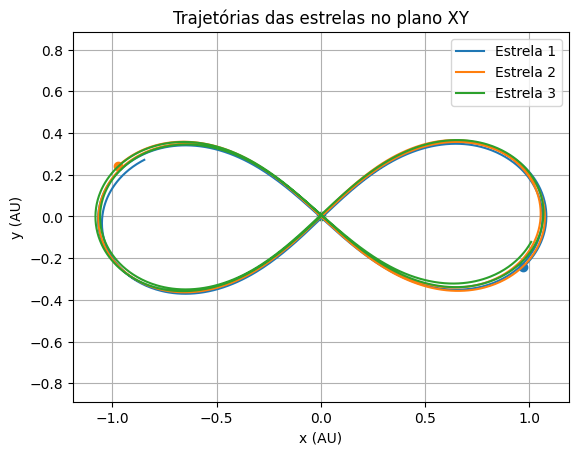

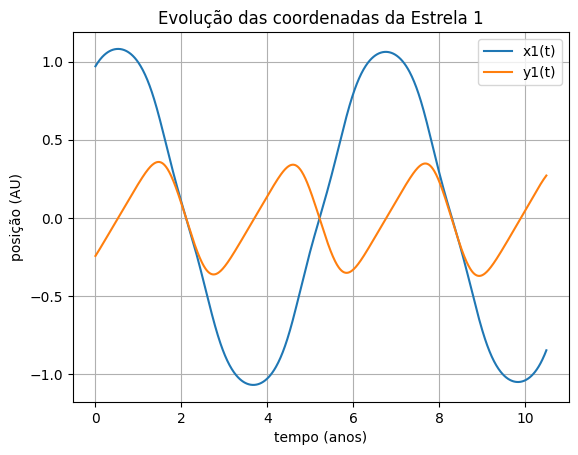

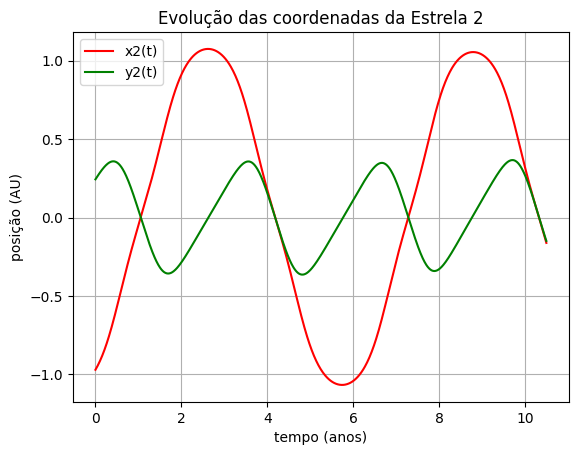

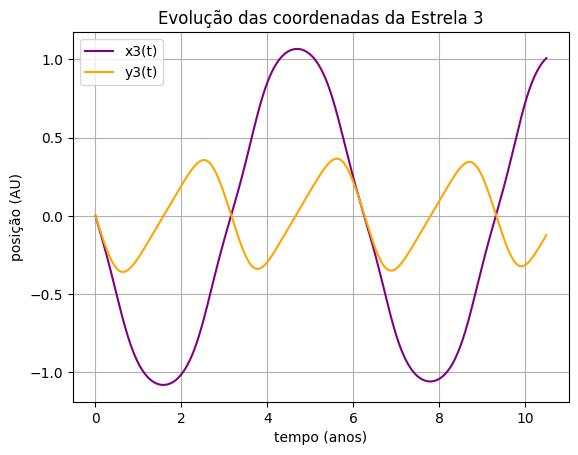

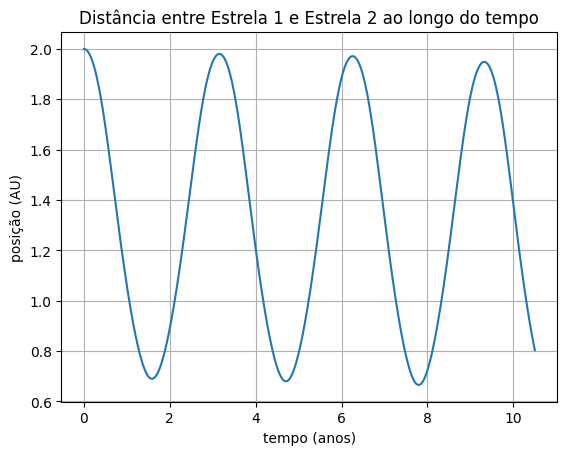

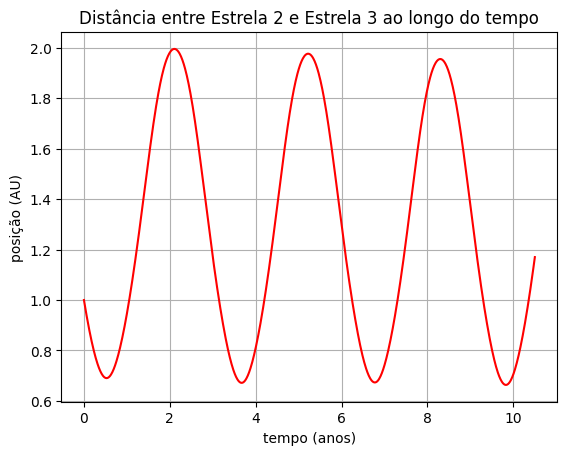

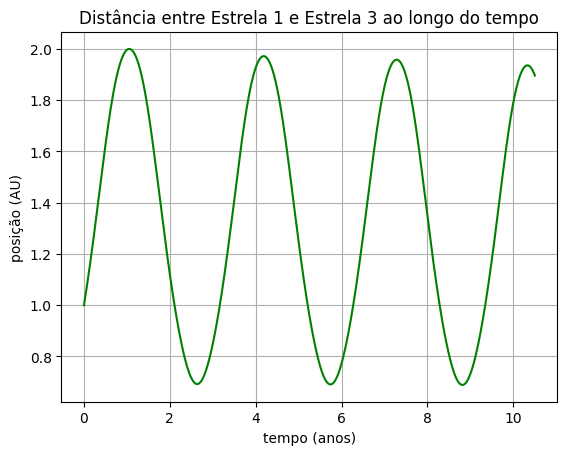

In [25]:
#Tarefa 2- letra b)

"""
 Mostre os gráficos das trajetórias de cada estrela no plano  XY ,
 da evolução das coordenadas de cada estrela e das distâncias mutuas entre as estrelas ao longo do tempo.

"""

# Gráfico de trajetória das Estrelas juntas
plt.plot(x1, y1, label="Estrela 1")
plt.plot(x2, y2, label="Estrela 2")
plt.plot(x3, y3, label="Estrela 3")

plt.scatter(x1[0], y1[0], marker="o")
plt.scatter(x2[0], y2[0], marker="o")
plt.scatter(x3[0], y3[0], marker="o")

plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Trajetórias das estrelas no plano XY")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

# Grafico da evolução das coordenadas de cada corpo ao longo do tempo
plt.plot(t, x1, label="x1(t)")
plt.plot(t, y1, label="y1(t)")
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Evolução das coordenadas da Estrela 1")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(t, x2, label="x2(t)", color="red")
plt.plot(t, y2, label="y2(t)", color="green")
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Evolução das coordenadas da Estrela 2")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(t, x3, label="x3(t)", color="purple")
plt.plot(t, y3, label="y3(t)", color="orange")
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Evolução das coordenadas da Estrela 3")
plt.legend()
plt.grid(True)
plt.show()

# Grafico da distância entre os dois corpos ao longo do tempo

dist1 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
dist2= np.sqrt((x2 - x3)**2 + (y2 - y3)**2)
dist3 = np.sqrt((x1 - x3)**2 + (y1 - y3)**2)

plt.plot(t, dist1)
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Distância entre Estrela 1 e Estrela 2 ao longo do tempo")
plt.grid(True)
plt.show()

plt.plot(t, dist2, color = "red")
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Distância entre Estrela 2 e Estrela 3 ao longo do tempo")
plt.grid(True)
plt.show()

plt.plot(t, dist3,color="green")
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Distância entre Estrela 1 e Estrela 3 ao longo do tempo")
plt.grid(True)
plt.show()


In [26]:
#Tarefa 2- letra c)

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

"""
Calcule a evolução do sistema para um período de  10.5anos . Use os seguintes dados:

Estrela 1:
x0 = 0.970043 ,  y0 = −0.243087 ,
v0x = 0.166203 ,  v0y = 0.432365 ,
m1 = 0.02533

Estrela 2:
x0 = -0.970043 ,  y0 = 0.243087 ,
v0x = 0.766203 ,  v0y = 0.432365 ,
m2 = 0.02533

Estrela 3:
x0 = 0.0 ,  y0 = 0.0 ,
v0x = -0.932406 ,  v0y = -0.864730 ,
m3 = 0.02533
"""
G = 4 * np.pi**2
tf = 10.5

#Condições iniciais Estrela 1
r1 = np.array([0.970043 , -0.243087 ])
v1 = np.array([0.166203 , 0.432365 ])
m1 = 0.02533

#Condições iniciais Estrela 2
r2 = np.array([ -0.970043 , 0.243087 ])
v2 = np.array([ 0.766203 , 0.432365])
m2 = 0.02533

#Condições iniciais Estrela 3
r3 = np.array([ 0.0 , 0.0 ])
v3 = np.array([ -0.932406 , -0.864730])
m3 = 0.02533


# Estado inicial
m = np.array([m1, m2, m3])
Y0 = np.concatenate((r1, v1, r2, v2, r3, v3))

def sistema_3_estrela(t,Y):
  r1 = Y[0:2]
  v1 = Y[2:4]

  r2 = Y[4:6]
  v2 = Y[6:8]

  r3 = Y[8:10]
  v3 = Y[10:12]

  # Criando novos vetores
  pos = [r1,r2,r3]
  acel = np.zeros((3,2))

  for i in range(3):
    for j in range(3):
      if i != j:
        r = pos[j] - pos[i]
        r_mod = np.linalg.norm(r)
        e = r / r_mod

        # F = ma, então a aceleração será:
        # Cada estrela sofre atração uma da outra, então precisa somar
        acel[i] += (G * m[j] / r_mod**2) * e # acel[0] = (G * m[1] / r_mod**2) * e + (G * m[2] / r_mod**2) * e ...

  a1 = acel[0]
  a2 = acel[1]
  a3 = acel[2]

  return np.concatenate([v1, a1, v2, a2, v3, a3])

# Pontos de tempo
t = np.linspace(0, tf, num=1000)

# Resolução numérica com solve_ivp
sol = solve_ivp(sistema_3_estrela, (0, tf), Y0, t_eval=t)

print(sol.success)
t = sol.t
x1 = sol.y[0]
y1 = sol.y[1]
vx1 = sol.y[2]
vy1 = sol.y[3]

x2 = sol.y[4]
y2 = sol.y[5]
vx2 = sol.y[6]
vy2 = sol.y[7]

x3 = sol.y[8]
y3 = sol.y[9]
vx3 = sol.y[10]
vy3 = sol.y[11]

print("Posição final da Estrela 1:" , x1[-1], y1[-1])
print("Velocidade final da Estrela 1:" , vx1[-1], vy1[-1])
print("Posição final da Estrela 2:" , x2[-1], y2[-1])
print("Velocidade final da Estrela 2:" , vx2[-1], vy2[-1])
print("Posição final da Estrela 3:" , x3[-1], y3[-1])
print("Velocidade final da Estrela 3:" , vx3[-1], vy3[-1])

True
Posição final da Estrela 1: 1.2807887854255322 -0.7993312782265183
Velocidade final da Estrela 1: 0.026693890930904865 -0.4123295642994039
Posição final da Estrela 2: -0.8388897505274596 -0.24563213376961718
Velocidade final da Estrela 2: 0.502043738894181 0.33659081849114303
Posição final da Estrela 3: -0.4418990348980794 1.0449634119961364
Velocidade final da Estrela 3: -0.5287376298250875 0.07573874580826212


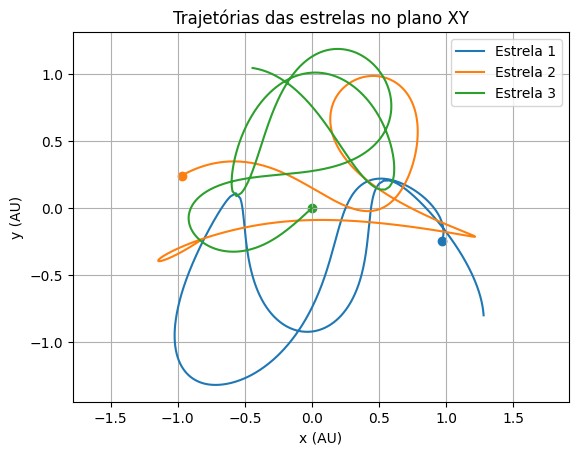

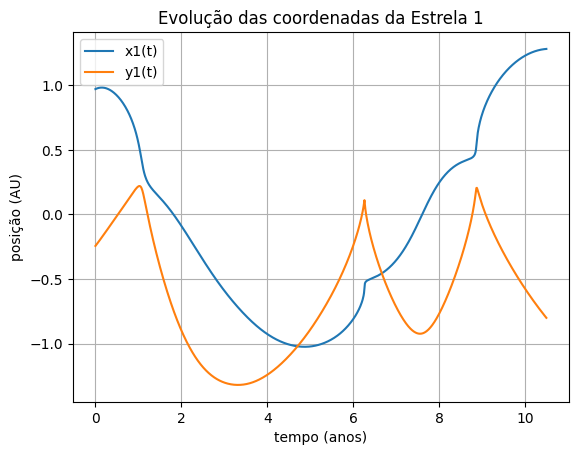

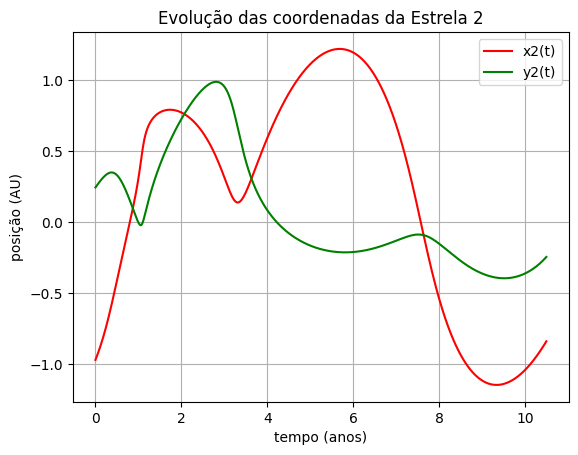

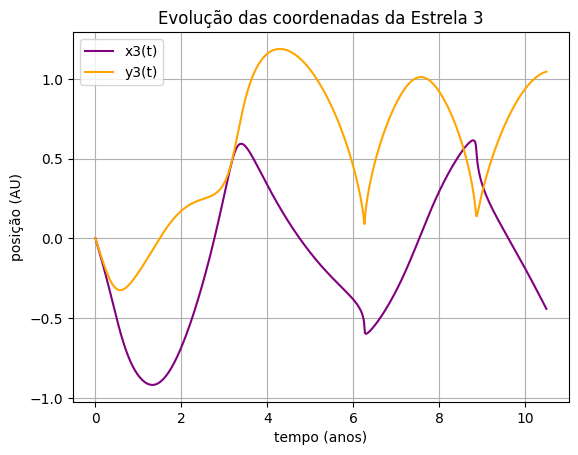

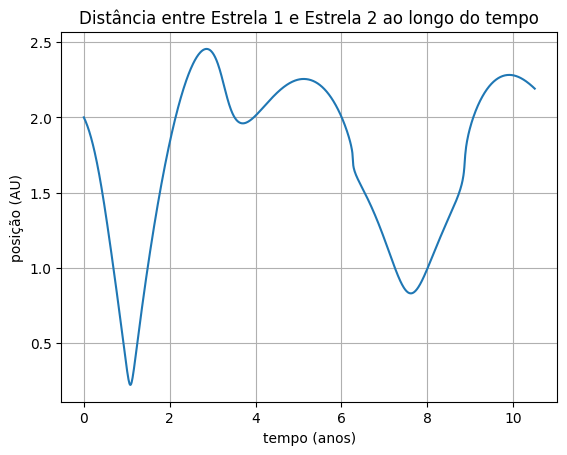

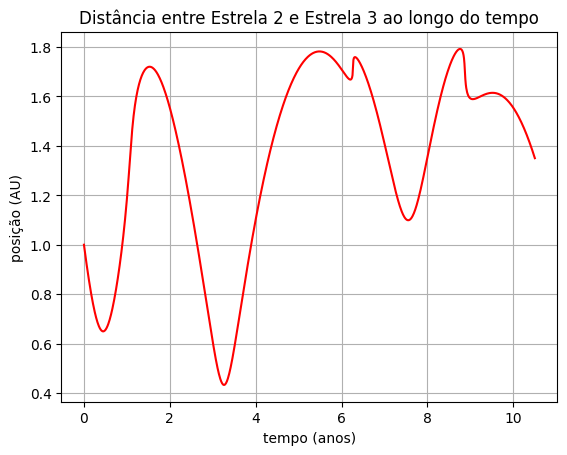

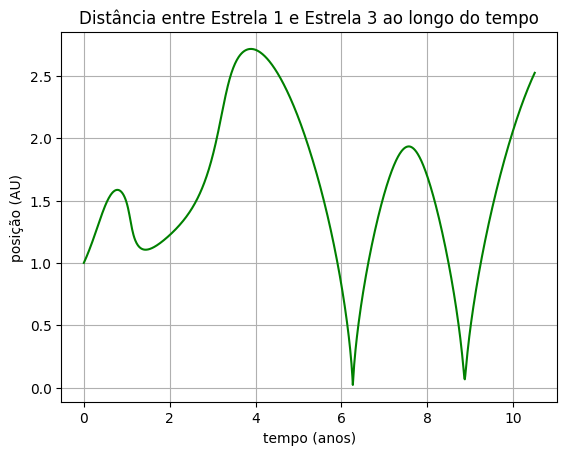

In [27]:
#Tarefa 2- letra d)

"""
 Mostre os gráficos das trajetórias de cada estrela no plano  XY ,
 da evolução das coordenadas de cada estrela e das distâncias mutuas entre as estrelas ao longo do tempo.

"""

# Gráfico de trajetória das Estrelas juntas
plt.plot(x1, y1, label="Estrela 1")
plt.plot(x2, y2, label="Estrela 2")
plt.plot(x3, y3, label="Estrela 3")

plt.scatter(x1[0], y1[0], marker="o")
plt.scatter(x2[0], y2[0], marker="o")
plt.scatter(x3[0], y3[0], marker="o")

plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.title("Trajetórias das estrelas no plano XY")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

# Grafico da evolução das coordenadas de cada corpo ao longo do tempo
plt.plot(t, x1, label="x1(t)")
plt.plot(t, y1, label="y1(t)")
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Evolução das coordenadas da Estrela 1")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(t, x2, label="x2(t)", color="red")
plt.plot(t, y2, label="y2(t)", color="green")
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Evolução das coordenadas da Estrela 2")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(t, x3, label="x3(t)", color="purple")
plt.plot(t, y3, label="y3(t)", color="orange")
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Evolução das coordenadas da Estrela 3")
plt.legend()
plt.grid(True)
plt.show()

# Grafico da distância entre os dois corpos ao longo do tempo

dist1 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
dist2= np.sqrt((x2 - x3)**2 + (y2 - y3)**2)
dist3 = np.sqrt((x1 - x3)**2 + (y1 - y3)**2)

plt.plot(t, dist1)
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Distância entre Estrela 1 e Estrela 2 ao longo do tempo")
plt.grid(True)
plt.show()

plt.plot(t, dist2, color = "red")
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Distância entre Estrela 2 e Estrela 3 ao longo do tempo")
plt.grid(True)
plt.show()

plt.plot(t, dist3,color="green")
plt.xlabel("tempo (anos)")
plt.ylabel("posição (AU)")
plt.title("Distância entre Estrela 1 e Estrela 3 ao longo do tempo")
plt.grid(True)
plt.show()


## Relatório

*(Escreva aqui seu relatório.)*